In [17]:
import pandas as pd

In [18]:
df = pd.read_csv("mobile_price.csv")

In [19]:
df.head()

,ram_gb,storage_gb,battery_mah,camera_mp,display_in,processor_score,price
0,4,64,5000,48,6.5,342,43249
1,16,64,6000,108,6.1,230,68977
2,6,128,6000,200,6.1,774,77558
3,16,512,4500,108,6.7,206,93397
4,12,256,5000,48,6.5,981,87062


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ram_gb           500 non-null    int64  
 1   storage_gb       500 non-null    int64  
 2   battery_mah      500 non-null    int64  
 3   camera_mp        500 non-null    int64  
 4   display_in       500 non-null    float64
 5   processor_score  500 non-null    int64  
 6   price            500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [21]:
df.isnull().sum()

,0
ram_gb,0
storage_gb,0
battery_mah,0
camera_mp,0
display_in,0
processor_score,0
price,0


In [22]:
df.describe()

,ram_gb,storage_gb,battery_mah,camera_mp,display_in,processor_score,price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,9.236000,241.152000,5031.000000,87.360000,6.540600,614.206000,75847.420000
std,4.254469,171.210335,700.371359,63.537204,0.265995,231.433815,15594.668981
min,4.000000,64.000000,4000.000000,12.000000,6.100000,203.000000,40222.000000
25%,6.000000,64.000000,4500.000000,48.000000,6.500000,419.750000,63330.000000
50%,8.000000,256.000000,5000.000000,64.000000,6.700000,622.000000,75463.000000
75%,12.000000,256.000000,5500.000000,108.000000,6.800000,815.250000,86611.750000
max,16.000000,512.000000,6000.000000,200.000000,6.800000,997.000000,118205.000000


In [23]:
x = df.drop("price",axis=1)
y = df["price"]

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [25]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 6)
(100, 6)
(400,)
(100,)


In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model = LinearRegression()

Model Training


In [28]:
model.fit(x_train, y_train)

LinearRegression()

In [29]:
y_pred = model.predict(x_test)

In [30]:
print(y_pred[:10])

[74954.71299701 59503.21642799 78555.76151204 94824.788726
 76944.60277813 65431.62078601 66798.53127308 55637.48209834
 74916.70422484 60717.27634972]


In [41]:
comparison = x_test.copy()
comparison["Actual Price"] = y_test
comparison["Predicted Price"] = y_pred

Actual vs Predicted Table

In [42]:
comparison.head(10)

,ram_gb,storage_gb,battery_mah,camera_mp,display_in,processor_score,Actual Price,Predicted Price
361,8,256,5500,108,6.7,515,74197,74954.712997
73,6,64,4000,48,6.8,825,56981,59503.216428
374,16,256,5000,64,6.8,280,78776,78555.761512
155,6,512,5000,108,6.7,882,92066,94824.788726
104,8,256,6000,64,6.1,729,75410,76944.602778
394,12,128,4000,48,6.8,482,65899,65431.620786
377,12,64,4000,48,6.1,711,67189,66798.531273
124,8,128,4000,12,6.5,514,57384,55637.482098
68,8,128,4500,108,6.8,893,73350,74916.704225
450,12,64,4000,12,6.7,576,60071,60717.276350


In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

In [33]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1596.2848216839454


In [34]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9875500873420625


Scatter Plot

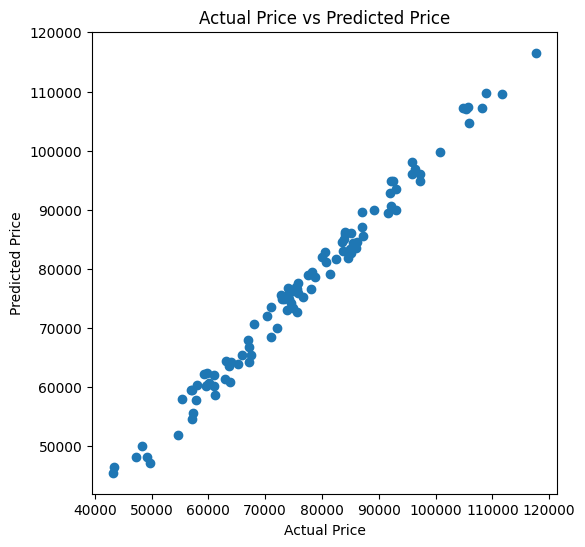

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

plt.show()

Line Graph

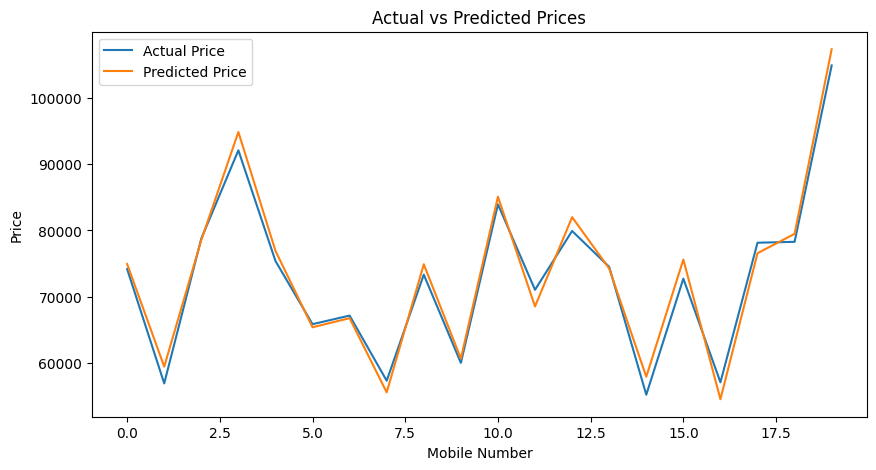

In [36]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:20], label="Actual Price")
plt.plot(y_pred[:20], label="Predicted Price")

plt.xlabel("Mobile Number")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")
plt.legend()

plt.show()

In [37]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [1790.56898451   59.49121906    2.00861179   88.51998995  831.89902298
   25.1383311 ]
Intercept: 6272.921296626388


Some unseen data testing
Example-1

In [38]:
new_mobile = [[8, 128, 5000, 64, 6.5, 750]]

predicted_price = model.predict(new_mobile)

print("Predicted Price: ₹", predicted_price[0])

Predicted Price: ₹ 68181.77950860656


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [39]:
new_mobile = [[12, 256, 6000, 108, 6.8, 950]]

predicted_price = model.predict(new_mobile)

print("Predicted Price: ₹", predicted_price[0])

Predicted Price: ₹ 94139.6587639667


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [40]:
new_mobiles = [
    [4, 64, 4500, 48, 6.1, 450],
    [8, 128, 5000, 64, 6.5, 700],
    [12, 256, 6000, 108, 6.8, 950],
    [16, 512, 6000, 200, 6.8, 1000]
]

predictions = model.predict(new_mobiles)

for i, price in enumerate(predictions, start=1):
    print(f"Mobile {i}: ₹{price:.2f}")

Mobile 1: ₹46917.18
Mobile 2: ₹66924.86
Mobile 3: ₹94139.66
Mobile 4: ₹125932.44


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
